In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import seaborn as sns

In [9]:
palette = sns.color_palette('deep')
palette

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [10]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = True

$$V_i^+ = (1 - c) \left(V_i + D \sum_j^{n} \left(\frac{V_j - V_i}{d_{ij}^2}\right)\right)$$

$$IFN_i^+ = (1 - c_F) \left(IFN_i + D_F \sum_j^{n} \left(\frac{IFN_j - IFN_i}{d_{ij}^2}\right)\right)$$

In [5]:
def sigFunc(x, A, K):
    return (1 + np.exp(-A*(x-K)))**-1

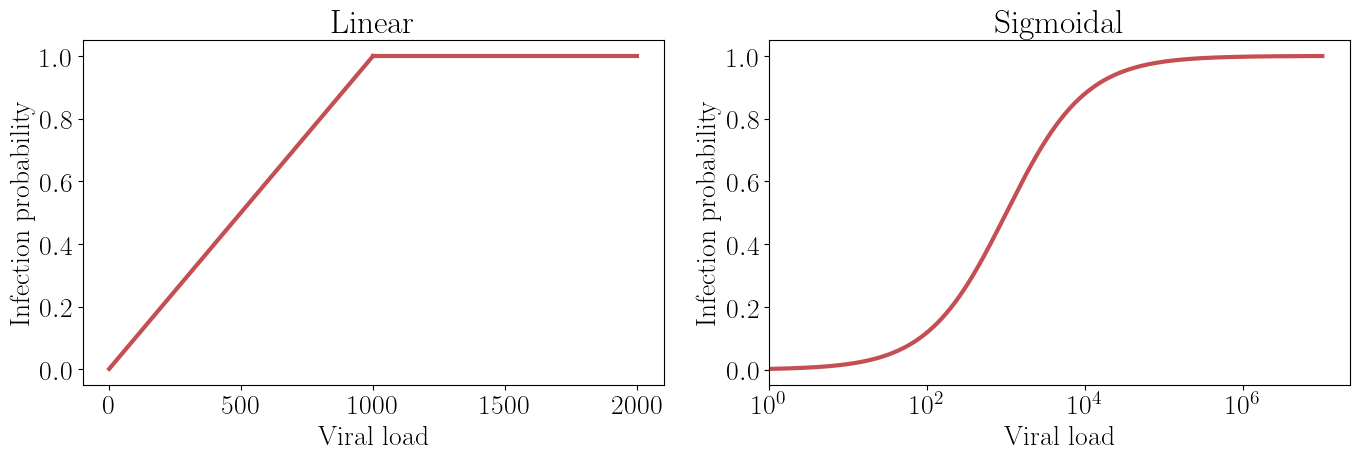

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5),facecolor='white')

A_V = 2
K_V = 3

xx1 = np.linspace(1, 1e3, num=1000)
xx2 = np.linspace(1e3, 2e3, num=1000)
yy1 = 0.001*xx1
yy2 = np.ones(len(xx2))

axs[0].set_title("Linear")
axs[0].plot(xx1, yy1, lw=3, color=palette[3])
axs[0].plot(xx2, yy2, lw=3, color=palette[3])
axs[0].set_xlabel('Viral load')
axs[0].set_ylabel('Infection probability')

xx = np.linspace(0, 7, num=1000)
x = 10**(xx)
yy1 = sigFunc(xx, A_V, K_V)

axs[1].set_title("Sigmoidal")
axs[1].plot(x, yy1, lw=3, color=palette[3])
axs[1].set_xlabel('Viral load')
axs[1].set_ylabel('Infection probability')
axs[1].set_xscale('log')
axs[1].set_xlim((1))

plt.tight_layout()
plt.savefig('probFunctionV.png')

plt.show()

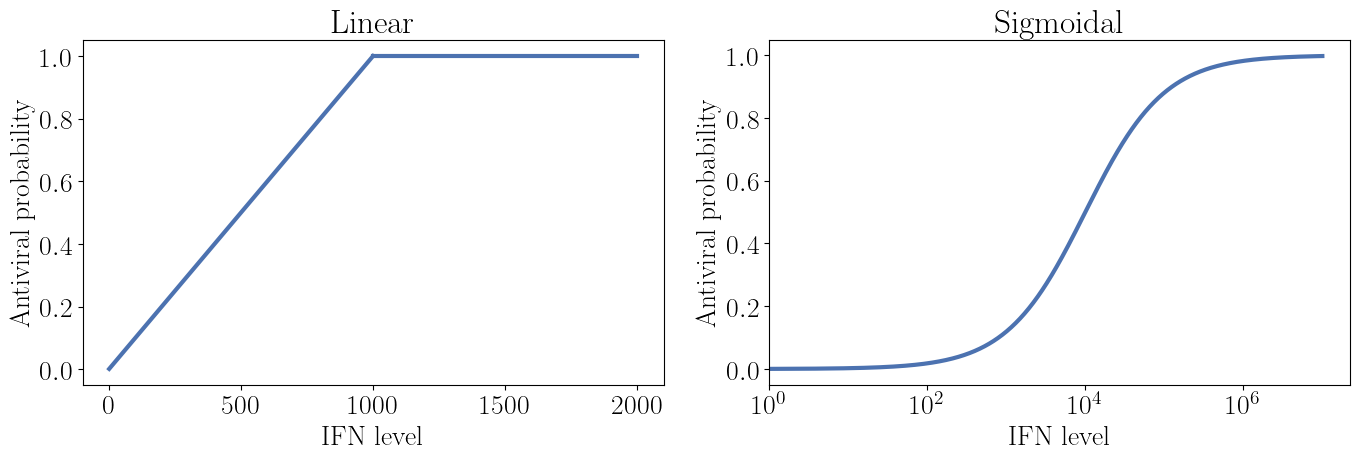

In [7]:
# fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,8),facecolor='white')
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5),facecolor='white')

A_V = 2
K_V = 4

xx1 = np.linspace(1, 1e3, num=1000)
xx2 = np.linspace(1e3, 2e3, num=1000)
yy1 = 0.001*xx1
yy2 = np.ones(len(xx2))

axs[0].set_title("Linear")
axs[0].plot(xx1, yy1, lw=3, color=palette[0])
axs[0].plot(xx2, yy2, lw=3, color=palette[0])
axs[0].set_xlabel('IFN level')
axs[0].set_ylabel('Antiviral probability')

xx = np.linspace(0, 7, num=1000)
x = 10**(xx)
yy1 = sigFunc(xx, A_V, K_V)

axs[1].set_title("Sigmoidal")
axs[1].plot(x, yy1, lw=3, color=palette[0])
axs[1].set_xlabel('IFN level')
axs[1].set_ylabel('Antiviral probability')
axs[1].set_xscale('log')
axs[1].set_xlim((1))

plt.tight_layout()
plt.savefig('probFunctionIFN.png')

plt.show()

In [14]:
# Load data
df = pd.read_csv('virions_per_cell.csv')
x = df['Time'].values
y = df['Virions'].values

In [29]:
# Define sigmoidal (logistic) function
def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

# Derivative of sigmoid
def sigmoid_derivative(t, L, k, t0):
    exp_term = np.exp(-k * (t - t0))
    return (L * k * exp_term) / (1 + exp_term)**2

In [30]:
# Initial guess: L=max, k=1, t0=midpoint
p0 = [max(y), 1, np.median(x)]

# Fit
popt, _ = curve_fit(sigmoid, x, y, p0, maxfev=10000)
L, k, t0 = popt

# Generate fitted curve
x_fit = np.linspace(min(x), max(x), 200)
y_fit = sigmoid(x_fit, *popt)

# Compute derivative
y_derivative = sigmoid_derivative(x_fit, *popt)

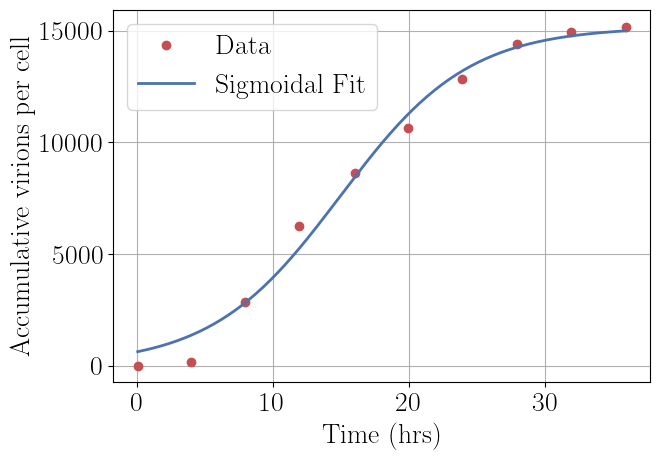

In [32]:
# Plot
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x, y, 'o', label='Data', color=palette[3])
plt.plot(x_fit, y_fit, '-', lw=2, label='Sigmoidal Fit', color=palette[0])
plt.xlabel('Time (hrs)')
plt.ylabel('Accumulative virions per cell')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('viralProduction.png')
plt.show()

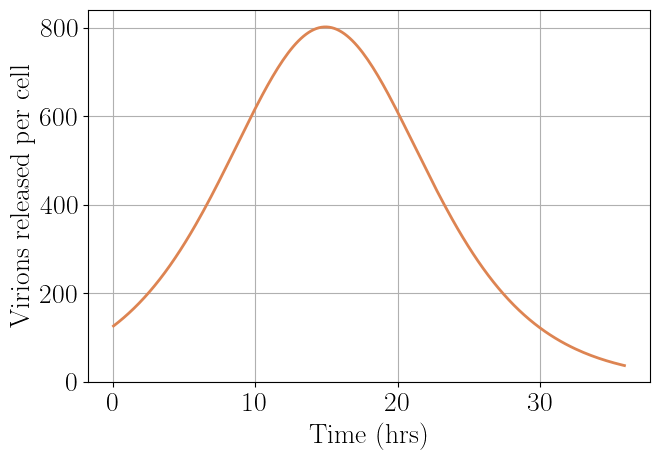

In [34]:
# Plot
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x_fit, y_derivative, '-', lw=2, label='Virion release rate', color=palette[1])
plt.xlabel('Time (hrs)')
plt.ylabel('Virions released per cell')
plt.grid(True)
plt.tight_layout()

plt.savefig('viralRate.png')
plt.show()